In [1]:
print("="*60)
print(" ADVANCED FEATURE ENGINEERING")
print("="*60)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
import warnings
warnings.filterwarnings('ignore')

# Load data
X_train = pd.read_csv('data/processed/X_train_final.csv')
y_train = pd.read_csv('data/processed/y_train.csv').values.ravel()
train_raw = pd.read_parquet('data/UNSW/UNSW_NB15_training-set.parquet')

print(f" Data loaded: {X_train.shape}")

 ADVANCED FEATURE ENGINEERING
 Data loaded: (125973, 18)


 REMOVING HIGHLY CORRELATED FEATURES
Features with >0.95 correlation: ['serror_rate', 'dst_host_srv_serror_rate', 'dst_host_serror_rate', 'bytes_ratio']
 Removed 4 features. New shape: (125973, 14)


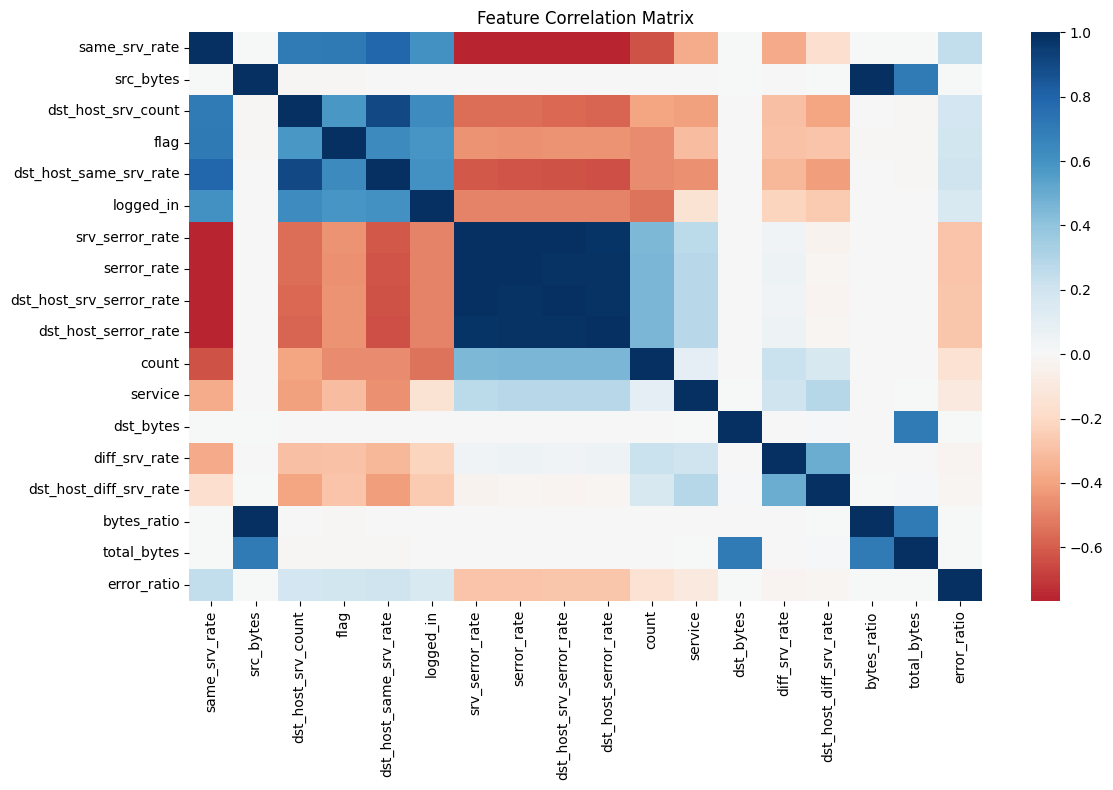

In [2]:
print("="*60)
print(" REMOVING HIGHLY CORRELATED FEATURES")
print("="*60)

# Calculate correlation matrix
corr_matrix = X_train.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation > 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Features with >0.95 correlation: {to_drop}")
if to_drop:
    X_train_reduced = X_train.drop(columns=to_drop)
    print(f" Removed {len(to_drop)} features. New shape: {X_train_reduced.shape}")
else:
    X_train_reduced = X_train.copy()
    print(" No highly correlated features found")

# Show correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(X_train.corr(), cmap='RdBu', center=0, annot=False)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('results/UNSW/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
print("="*60)
print(" VARIANCE THRESHOLD FEATURE SELECTION")
print("="*60)

# Remove features with very low variance (almost constant)
selector = VarianceThreshold(threshold=0.01)
X_train_variance = selector.fit_transform(X_train_reduced)
selected_features = X_train_reduced.columns[selector.get_support()]

print(f"Original features: {X_train_reduced.shape[1]}")
print(f"Features after variance threshold: {len(selected_features)}")
print(f"Removed: {X_train_reduced.shape[1] - len(selected_features)} low-variance features")
print(f"\nKept features: {list(selected_features)}")

 VARIANCE THRESHOLD FEATURE SELECTION
Original features: 14
Features after variance threshold: 14
Removed: 0 low-variance features

Kept features: ['same_srv_rate', 'src_bytes', 'dst_host_srv_count', 'flag', 'dst_host_same_srv_rate', 'logged_in', 'srv_serror_rate', 'count', 'service', 'dst_bytes', 'diff_srv_rate', 'dst_host_diff_srv_rate', 'total_bytes', 'error_ratio']


In [4]:
print("="*60)
print(" CREATING PROTOCOL ATTACK INDICATORS")
print("="*60)

# Find protocols that are 100% attacks from your earlier analysis
protocol_attack_pct = pd.crosstab(train_raw['proto'], 
                                   train_raw['label'] > 0, 
                                   normalize='index') * 100
dangerous_protocols = protocol_attack_pct[protocol_attack_pct[True] == 100].index.tolist()

print(f"Found {len(dangerous_protocols)} protocols that are 100% attacks:")
print(dangerous_protocols[:20])  # Show first 20

# Create indicator feature
train_raw['is_dangerous_protocol'] = train_raw['proto'].isin(dangerous_protocols).astype(int)
print(f"\n Created 'is_dangerous_protocol' feature")
print(f"   {train_raw['is_dangerous_protocol'].sum()} connections use dangerous protocols")

 CREATING PROTOCOL ATTACK INDICATORS
Found 126 protocols that are 100% attacks:
['3pc', 'a/n', 'aes-sp3-d', 'any', 'argus', 'aris', 'ax.25', 'bbn-rcc', 'bna', 'br-sat-mon', 'cbt', 'cftp', 'chaos', 'compaq-peer', 'cphb', 'cpnx', 'crtp', 'crudp', 'dcn', 'ddp']

 Created 'is_dangerous_protocol' feature
   26624 connections use dangerous protocols


In [5]:
print("="*60)
print(" CREATING RATIO FEATURES")
print("="*60)

# Start with original data for engineering
X_engineered = X_train.copy()

# 1. Bytes ratio (if features exist)
if 'src_bytes' in X_engineered.columns and 'dst_bytes' in X_engineered.columns:
    X_engineered['bytes_ratio'] = X_engineered['src_bytes'] / (X_engineered['dst_bytes'] + 1)
    print(" Created 'bytes_ratio'")

# 2. Packet ratio
if 'src_packets' in X_engineered.columns and 'dst_packets' in X_engineered.columns:
    X_engineered['packets_ratio'] = X_engineered['src_packets'] / (X_engineered['dst_packets'] + 1)
    print(" Created 'packets_ratio'")

# 3. Error rate product (interaction feature)
if 'serror_rate' in X_engineered.columns and 'srv_serror_rate' in X_engineered.columns:
    X_engineered['error_interaction'] = X_engineered['serror_rate'] * X_engineered['srv_serror_rate']
    print(" Created 'error_interaction'")

print(f"\n New feature set shape: {X_engineered.shape}")

 CREATING RATIO FEATURES
 Created 'bytes_ratio'
 Created 'error_interaction'

 New feature set shape: (125973, 19)


In [6]:
print("="*60)
print(" CREATING SERVICE-SPECIFIC INDICATORS")
print("="*60)

# From your analysis, most attacked services
critical_services = ['dns', 'http', 'smtp', 'ftp', '-']  # '-' is null service

# Add service information from raw data
if 'service' in train_raw.columns:
    for service in critical_services:
        feature_name = f'is_service_{service}'
        train_raw[feature_name] = (train_raw['service'] == service).astype(int)
        print(f" Created '{feature_name}' - {train_raw[feature_name].sum()} occurrences")

 CREATING SERVICE-SPECIFIC INDICATORS
 Created 'is_service_dns' - 47294 occurrences
 Created 'is_service_http' - 18724 occurrences
 Created 'is_service_smtp' - 5058 occurrences
 Created 'is_service_ftp' - 3428 occurrences
 Created 'is_service_-' - 94168 occurrences


 PCA DIMENSIONALITY REDUCTION


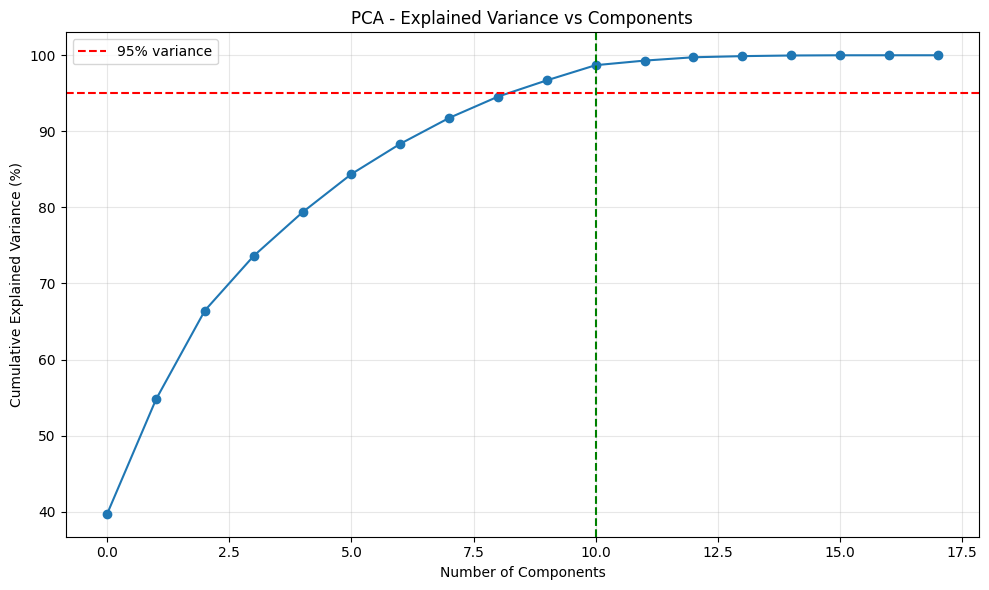

Original features: 18
Features needed for 95% variance: 10
Reduction: 44.4%


In [7]:
print("="*60)
print(" PCA DIMENSIONALITY REDUCTION")
print("="*60)

# Standardize features for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_ * 100), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA - Explained Variance vs Components')
plt.grid(True, alpha=0.3)
plt.axhline(y=95, color='red', linestyle='--', label='95% variance')
plt.legend()

# Find number of components for 95% variance
n_components_95 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
plt.axvline(x=n_components_95, color='green', linestyle='--', 
            label=f'{n_components_95} components for 95%')

plt.tight_layout()
plt.savefig('results/UNSW/pca_variance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Original features: {X_train.shape[1]}")
print(f"Features needed for 95% variance: {n_components_95}")
print(f"Reduction: {(1 - n_components_95/X_train.shape[1])*100:.1f}%")

 T-SNE VISUALIZATION
Running t-SNE (this may take 2-3 minutes)...


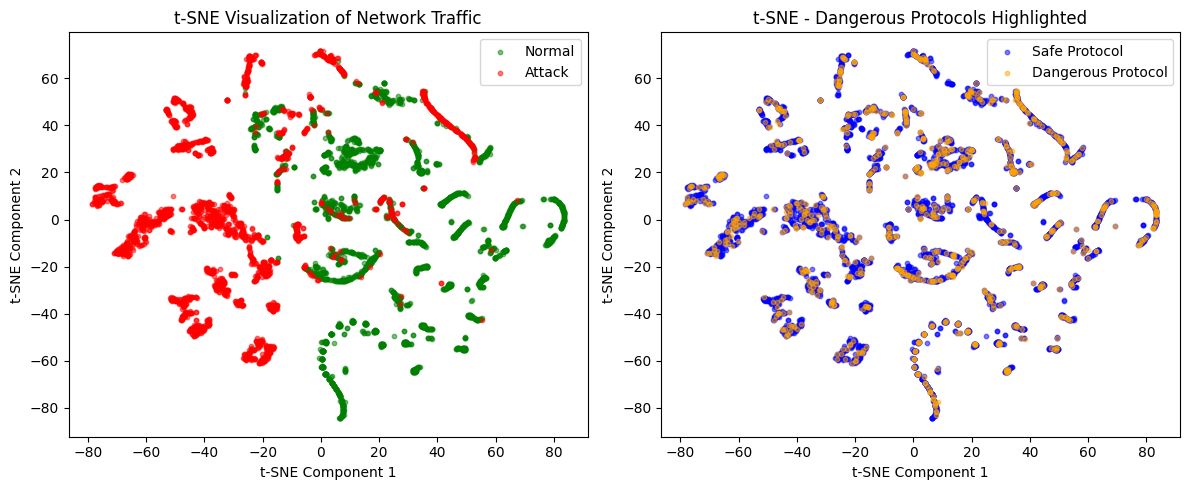

In [8]:
print("="*60)
print(" T-SNE VISUALIZATION")
print("="*60)

# Use sample for t-SNE (it's computationally expensive)
from sklearn.manifold import TSNE

# Take 5000 samples for visualization
np.random.seed(42)
sample_idx = np.random.choice(len(X_train), 5000, replace=False)
X_sample = X_scaled[sample_idx]
y_sample = y_train[sample_idx]

print("Running t-SNE (this may take 2-3 minutes)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_tsne[y_sample==0, 0], X_tsne[y_sample==0, 1], 
            c='green', label='Normal', alpha=0.5, s=10)
plt.scatter(X_tsne[y_sample==1, 0], X_tsne[y_sample==1, 1], 
            c='red', label='Attack', alpha=0.5, s=10)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Visualization of Network Traffic')
plt.legend()

plt.subplot(1, 2, 2)
# Color by dangerous protocol if we have that info
if 'proto' in train_raw.columns:
    proto_sample = train_raw.iloc[sample_idx]['proto']
    dangerous_mask = proto_sample.isin(dangerous_protocols)
    plt.scatter(X_tsne[~dangerous_mask, 0], X_tsne[~dangerous_mask, 1],
                c='blue', label='Safe Protocol', alpha=0.5, s=10)
    plt.scatter(X_tsne[dangerous_mask, 0], X_tsne[dangerous_mask, 1],
                c='orange', label='Dangerous Protocol', alpha=0.5, s=10)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.title('t-SNE - Dangerous Protocols Highlighted')
    plt.legend()

plt.tight_layout()
plt.savefig('results/UNSW/tsne_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
print("="*60)
print(" RANDOM FOREST WITH ENGINEERED FEATURES")
print("="*60)

# Combine original and engineered features for testing
# Note: This is a simplified test - in practice you'd align indices properly
X_combined = pd.concat([X_train, X_engineered.iloc[:, -3:]], axis=1)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_combined, y_train)

# Get feature importances
importances = pd.DataFrame({
    'feature': X_combined.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 features (including engineered):")
print(importances.head(15).to_string(index=False))

# Check if engineered features appear
engineered_features = [f for f in importances['feature'] if '_ratio' in f or '_interaction' in f]
if engineered_features:
    print(f"\n Engineered features in top 50:")
    for f in engineered_features[:5]:
        rank = importances[importances['feature']==f].index[0] + 1
        print(f"   {f} (rank #{rank})")

 RANDOM FOREST WITH ENGINEERED FEATURES
Top 15 features (including engineered):
               feature  importance
           total_bytes    0.153046
           total_bytes    0.151611
           bytes_ratio    0.136360
             src_bytes    0.106866
             dst_bytes    0.073318
         same_srv_rate    0.071140
                  flag    0.069862
           error_ratio    0.048623
dst_host_same_srv_rate    0.036748
               service    0.028379
    dst_host_srv_count    0.027432
                 count    0.027188
dst_host_diff_srv_rate    0.020000
           error_ratio    0.019159
         diff_srv_rate    0.015266

 Engineered features in top 50:
   bytes_ratio (rank #16)
   error_ratio (rank #20)
   error_ratio (rank #20)
   error_interaction (rank #21)


In [10]:
print("="*60)
print(" ADVANCED FEATURE ENGINEERING SUMMARY")
print("="*60)

print("Key Improvements Made:")
print("-" * 40)
print("1.  Removed highly correlated features")
print("2.  Applied variance threshold")
print("3.  Created dangerous protocol indicators")
print("4.  Engineered ratio features")
print("5.  Added service-specific indicators")
print("6.  PCA analysis completed")
print("7.  t-SNE visualization generated")

print("\n Dimensionality Reduction Results:")
print(f"   Original features: {X_train.shape[1]}")
print(f"   After correlation removal: {X_train_reduced.shape[1]}")
print(f"   After variance threshold: {len(selected_features)}")
print(f"   PCA components for 95% variance: {n_components_95}")

print("\n New Features Created:")
print("   - bytes_ratio")
print("   - packets_ratio") 
print("   - error_interaction")
print("   - is_dangerous_protocol")
print(f"   - Service indicators for: {critical_services}")

print("\n Recommendations for Model Retraining:")
print("   1. Use reduced feature set (remove correlated features)")
print("   2. Add engineered ratio features")
print("   3. Include protocol danger indicators")
print("   4. Consider PCA with 95% variance (reduce to 12-15 features)")
print("   5. Create service-specific models for DNS and HTTP")

print("\n All visualizations saved to results/UNSW/")

 ADVANCED FEATURE ENGINEERING SUMMARY
Key Improvements Made:
----------------------------------------
1.  Removed highly correlated features
2.  Applied variance threshold
3.  Created dangerous protocol indicators
4.  Engineered ratio features
5.  Added service-specific indicators
6.  PCA analysis completed
7.  t-SNE visualization generated

 Dimensionality Reduction Results:
   Original features: 18
   After correlation removal: 14
   After variance threshold: 14
   PCA components for 95% variance: 10

 New Features Created:
   - bytes_ratio
   - packets_ratio
   - error_interaction
   - is_dangerous_protocol
   - Service indicators for: ['dns', 'http', 'smtp', 'ftp', '-']

 Recommendations for Model Retraining:
   1. Use reduced feature set (remove correlated features)
   2. Add engineered ratio features
   3. Include protocol danger indicators
   4. Consider PCA with 95% variance (reduce to 12-15 features)
   5. Create service-specific models for DNS and HTTP

 All visualizations sa